In [32]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon

import os
import json
import random

In [7]:
reg_mu    = np.load("/home/arbiter/projects/Survey-invariant-generalization/src/models/reg_mu.npy")
reg_sigma = np.load("/home/arbiter/projects/Survey-invariant-generalization/src/models/reg_sigma.npy")

experiments_dir = "/home/arbiter/projects/Survey-invariant-generalization/experiments/experiments_data"

seeds = [1, 7, 42, 85, 123, 156, 234, 301, 412, 500, 617, 724, 836, 901, 999, 1042]

## H1

Comparing reconstruction of spectra across experiment seeds

In [8]:
sdss_recon_maes = []
lamost_recon_maes = []

failed_seeds = []

for seed in seeds:

    seed_dir = os.path.join(experiments_dir, f"experiment_{seed}")
    
    try:
        sdss_flux = np.load(os.path.join(seed_dir, "sdss_flux.npy"))
        sdss_recon = np.load(os.path.join(seed_dir, "sdss_x_hat.npy"))

        lamost_flux = np.load(os.path.join(seed_dir, "lamost_flux.npy"))
        lamost_recon = np.load(os.path.join(seed_dir, "lamost_x_hat.npy"))

        # computing MAE
        sdss_mae = np.mean(np.abs(sdss_flux - sdss_recon))
        lamost_mae = np.mean(np.abs(lamost_flux - lamost_recon))

        sdss_recon_maes.append(sdss_mae)
        lamost_recon_maes.append(lamost_mae)

        print(f"Seed {seed:>4} | SDSS MAE: {sdss_mae:.4f} | LAMOST MAE: {lamost_mae:.4f}")

    except FileNotFoundError as e:
        print(f"Seed {seed} — missing files: {e}")
        failed_seeds.append(seed)


sdss_recon_maes   = np.array(sdss_recon_maes)
lamost_recon_maes = np.array(lamost_recon_maes)

# summary statistics

print("\n" + "=" * 50)
print("RECONSTRUCTION MAE ACROSS SEEDS")
print("=" * 50)
print(f"SDSS   MAE: {sdss_recon_maes.mean():.4f} ± {sdss_recon_maes.std():.4f}")
print(f"LAMOST MAE: {lamost_recon_maes.mean():.4f} ± {lamost_recon_maes.std():.4f}")
print(f"Ratio LAMOST/SDSS: {(lamost_recon_maes/sdss_recon_maes).mean():.4f}")

if failed_seeds:
    print(f"\nFailed seeds: {failed_seeds}")

# save results
results = {
    "seeds"             : seeds,
    "sdss_recon_maes"   : sdss_recon_maes.tolist(),
    "lamost_recon_maes" : lamost_recon_maes.tolist(),
    "sdss_mean"         : float(sdss_recon_maes.mean()),
    "sdss_std"          : float(sdss_recon_maes.std()),
    "lamost_mean"       : float(lamost_recon_maes.mean()),
    "lamost_std"        : float(lamost_recon_maes.std()),
    "ratio_mean"        : float((lamost_recon_maes/sdss_recon_maes).mean())
}

with open(os.path.join(experiments_dir, "recon_mae_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved to recon_mae_results.json")

Seed    1 | SDSS MAE: 0.1997 | LAMOST MAE: 0.1692
Seed    7 | SDSS MAE: 0.1977 | LAMOST MAE: 0.1651
Seed   42 | SDSS MAE: 0.1914 | LAMOST MAE: 0.1618
Seed   85 | SDSS MAE: 0.1902 | LAMOST MAE: 0.1611
Seed  123 | SDSS MAE: 0.1860 | LAMOST MAE: 0.1568
Seed  156 | SDSS MAE: 0.1940 | LAMOST MAE: 0.1623
Seed  234 | SDSS MAE: 0.1903 | LAMOST MAE: 0.1633
Seed  301 | SDSS MAE: 0.1906 | LAMOST MAE: 0.1629
Seed  412 | SDSS MAE: 0.1953 | LAMOST MAE: 0.1640
Seed  500 | SDSS MAE: 0.1939 | LAMOST MAE: 0.1665
Seed  617 | SDSS MAE: 0.1938 | LAMOST MAE: 0.1578
Seed  724 | SDSS MAE: 0.2003 | LAMOST MAE: 0.1633
Seed  836 | SDSS MAE: 0.1967 | LAMOST MAE: 0.1646
Seed  901 | SDSS MAE: 0.1893 | LAMOST MAE: 0.1618
Seed  999 | SDSS MAE: 0.1880 | LAMOST MAE: 0.1587
Seed 1042 | SDSS MAE: 0.1962 | LAMOST MAE: 0.1672

RECONSTRUCTION MAE ACROSS SEEDS
SDSS   MAE: 0.1933 ± 0.0040
LAMOST MAE: 0.1629 ± 0.0032
Ratio LAMOST/SDSS: 0.8427

Saved to recon_mae_results.json


#### Wilcoxon Ranked Test on reconstruction

In [10]:
stat, p = wilcoxon(
    lamost_recon_maes,
    sdss_recon_maes,
    alternative="greater"   # H1: LAMOST MAE > SDSS MAE
)

print("=== H1: Wilcoxon Signed-Rank Test ===")
print("H0: LAMOST reconstruction MAE > SDSS (generalisation failed)")
print("H1: LAMOST reconstruction MAE not significantly greater than SDSS")
print(f"Statistic: {stat:.4f}")
print(f"p-value:   {p:.4f}")
print(f"{'H1 SUPPORTED' if p > 0.05 else 'Generalisation degraded'}")

=== H1: Wilcoxon Signed-Rank Test ===
H0: LAMOST reconstruction MAE > SDSS (generalisation failed)
H1: LAMOST reconstruction MAE not significantly greater than SDSS
Statistic: 0.0000
p-value:   1.0000
H1 SUPPORTED


#### Reconstruction plots

In [28]:
best_recon_lamost_seed = np.where(lamost_recon_maes == min(lamost_recon_maes))[0][0]

In [47]:
best_recon_dir = os.path.join(experiments_dir, f"experiment_{seeds[best_recon_lamost_seed]}")
sdss_flux_best_seed = np.load(os.path.join(best_recon_dir, "sdss_flux.npy"))
sdss_recon_best_seed = np.load(os.path.join(best_recon_dir, "sdss_x_hat.npy"))

lamost_flux_best_seed = np.load(os.path.join(best_recon_dir, "lamost_flux.npy"))
lamost_recon_best_seed = np.load(os.path.join(best_recon_dir, "lamost_x_hat.npy"))

sdss_true_class = np.load(os.path.join(best_recon_dir, "sdss_true_cls.npy"))
sdss_pred_class = np.load(os.path.join(best_recon_dir, "sdss_preds_cls.npy"))

lamost_true_class = np.load(os.path.join(best_recon_dir, "lamost_true_cls.npy"))
lamost_pred_class = np.load(os.path.join(best_recon_dir, "lamost_preds_cls.npy"))

LAMBDA_START = 4000
LAMBDA_END = 8500
NUM_PIXELS = 3800

wavelength_grid = np.linspace(LAMBDA_START, LAMBDA_END, NUM_PIXELS)

SDSS Reconstruction

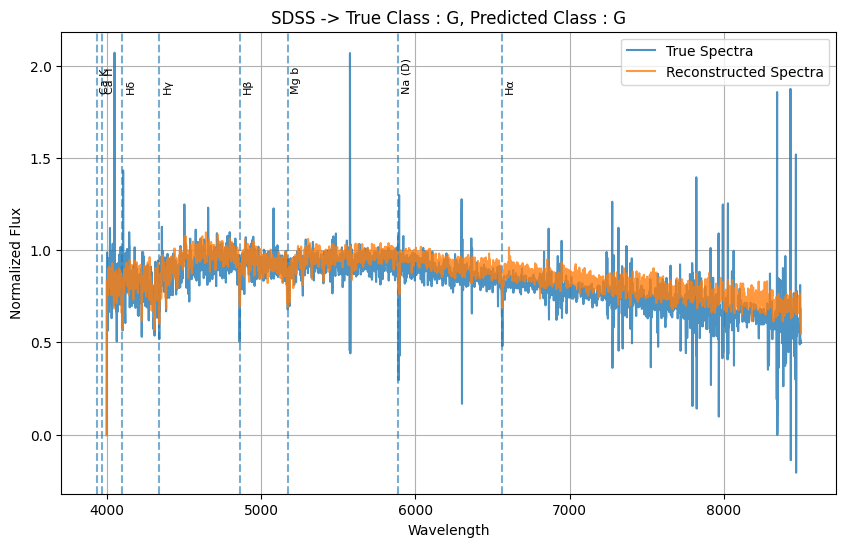

In [48]:

random_star_index_sdss = random.randint(0, 3241)
sdss_star_flux = sdss_flux_best_seed[random_star_index_sdss]
sdss_recon_flux = sdss_recon_best_seed[random_star_index_sdss]

sdss_true_cls = ""
sdss_pred_cls = ""
spectral_class_dict = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}
for i in spectral_class_dict:
    if spectral_class_dict[i] == sdss_true_class[random_star_index_sdss]:
        sdss_true_cls = i
    if spectral_class_dict[i] == sdss_pred_class[random_star_index_sdss]:
        sdss_pred_cls = i

spectral_lines = {
    "Hα": 6563,
    "Hβ": 4861,
    "Hγ": 4341,
    "Hδ": 4102,
    "Na (D)": 5890,
    "Ca K": 3934,
    "Ca H": 3969,
    "Mg b": 5175
}

plt.figure(figsize=(10,6))

# Plot vertical lines
for label, wl in spectral_lines.items():
    plt.axvline(x=wl, linestyle='--', alpha=0.6)
    plt.text(wl + 20, max(sdss_star_flux)*0.9, label, rotation=90, fontsize=8)

plt.title(f"SDSS -> True Class : {sdss_true_cls}, Predicted Class : {sdss_pred_cls}")
plt.grid()
plt.plot(wavelength_grid, sdss_star_flux, label = "True Spectra", alpha = 0.8)
plt.plot(wavelength_grid, sdss_recon_flux, label = "Reconstructed Spectra", alpha = 0.8)
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

LAMOST Reconstruction

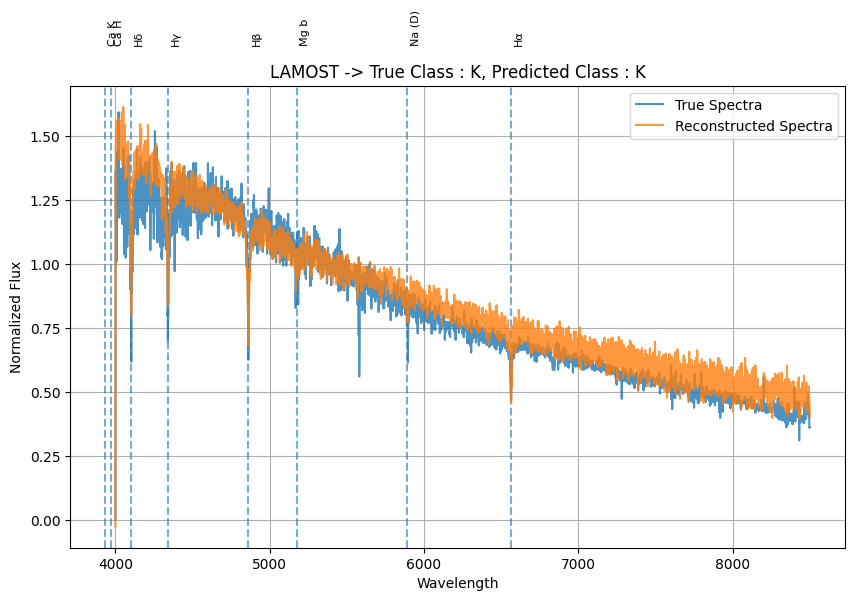

In [51]:
random_star_index_lamost = random.randint(0, 19799)
lamost_star_flux = lamost_flux_best_seed[random_star_index_lamost]
lamost_star_recon = lamost_recon_best_seed[random_star_index_lamost]

lamost_true_cls = ""
lamost_pred_cls = ""
spectral_class_dict = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}
for i in spectral_class_dict:
    if spectral_class_dict[i] == lamost_true_class[random_star_index_sdss]:
        lamost_true_cls = i
    if spectral_class_dict[i] == lamost_pred_class[random_star_index_sdss]:
        lamost_pred_cls = i

spectral_lines = {
    "Hα": 6563,
    "Hβ": 4861,
    "Hγ": 4341,
    "Hδ": 4102,
    "Na (D)": 5890,
    "Ca K": 3934,
    "Ca H": 3969,
    "Mg b": 5175
}

plt.figure(figsize=(10,6))

# Plot vertical lines
for label, wl in spectral_lines.items():
    plt.axvline(x=wl, linestyle='--', alpha=0.6)
    plt.text(wl + 20, max(sdss_star_flux)*0.9, label, rotation=90, fontsize=8)

plt.title(f"LAMOST -> True Class : {lamost_true_cls}, Predicted Class : {lamost_pred_cls}")
plt.grid()
plt.plot(wavelength_grid, lamost_star_flux, label = "True Spectra", alpha = 0.8)
plt.plot(wavelength_grid, lamost_star_recon, label = "Reconstructed Spectra", alpha = 0.8)
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

#### MAE Per Wavelength Pixel

Seed 1 done
Seed 7 done
Seed 42 done
Seed 85 done
Seed 123 done
Seed 156 done
Seed 234 done
Seed 301 done
Seed 412 done
Seed 500 done
Seed 617 done
Seed 724 done
Seed 836 done
Seed 901 done
Seed 999 done
Seed 1042 done


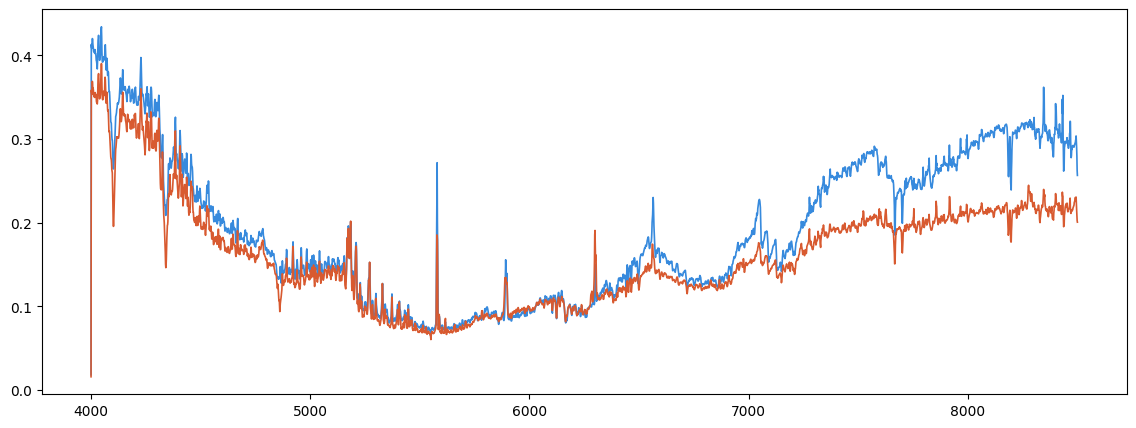

In [ ]:
spectral_lines = {
    "Hα": 6563, "Hβ": 4861, "Hγ": 4341, "Hδ": 4102,
    "Na D": 5890, "Mg b": 5175
}

# accumulate per-wavelength errors across seeds
sdss_per_pixel_all   = []
lamost_per_pixel_all = []

for seed in seeds:

    seed_dir = os.path.join(experiments_dir, f"experiment_{seed}")
    
    try:
        sdss_flux = np.load(os.path.join(seed_dir, "sdss_flux.npy"))
        sdss_recon = np.load(os.path.join(seed_dir, "sdss_x_hat.npy"))

        lamost_flux = np.load(os.path.join(seed_dir, "lamost_flux.npy"))
        lamost_recon = np.load(os.path.join(seed_dir, "lamost_x_hat.npy"))

        sdss_per_pixel = np.mean(np.abs(sdss_flux - sdss_recon), axis = 0)
        lamost_per_pixel = np.mean(np.abs(lamost_flux - lamost_recon), axis = 0)

        sdss_per_pixel_all.append(sdss_per_pixel)
        lamost_per_pixel_all.append(lamost_per_pixel)

        print(f"Seed {seed} done")

    except FileNotFoundError as e:
        print(f"Seed {seed} missing: {e}")

# stack into arrays — shape (n_seeds, 3800)
sdss_per_pixel_all   = np.array(sdss_per_pixel_all)
lamost_per_pixel_all = np.array(lamost_per_pixel_all)

# mean and std across seeds — shape (3800,)
sdss_mean   = sdss_per_pixel_all.mean(axis=0)
sdss_std    = sdss_per_pixel_all.std(axis=0)
lamost_mean = lamost_per_pixel_all.mean(axis=0)
lamost_std  = lamost_per_pixel_all.std(axis=0)

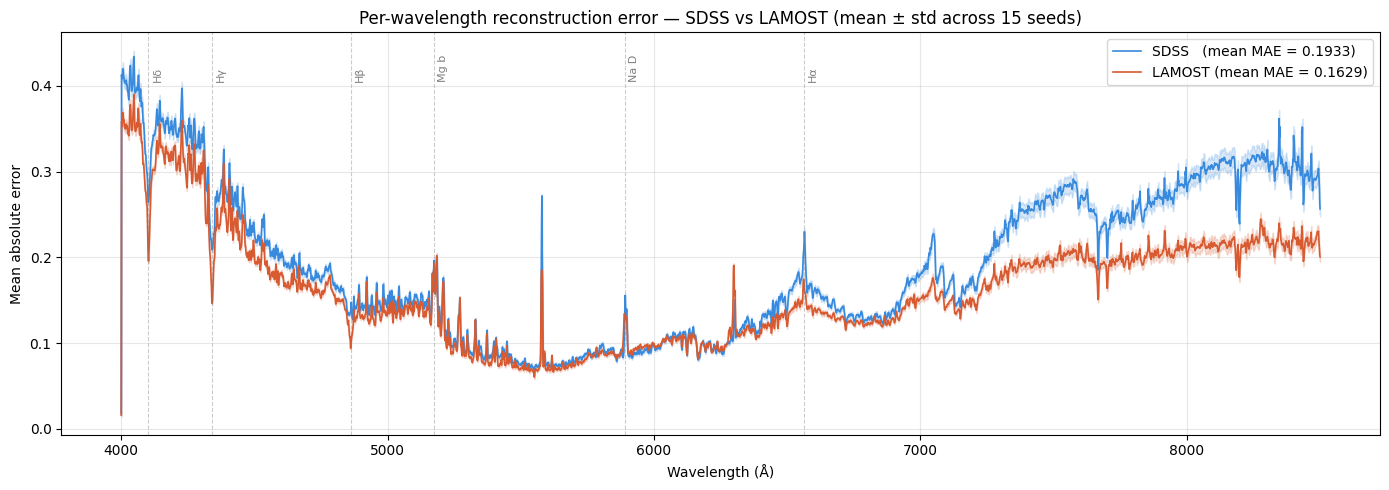

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

# mean lines
ax.plot(wavelength_grid, sdss_mean,
        label=f"SDSS   (mean MAE = {sdss_mean.mean():.4f})",
        color="#378ADD", linewidth=1.2)
ax.plot(wavelength_grid, lamost_mean,
        label=f"LAMOST (mean MAE = {lamost_mean.mean():.4f})",
        color="#D85A30", linewidth=1.2)

# uncertainty bands across seeds
ax.fill_between(wavelength_grid,
                sdss_mean - sdss_std,
                sdss_mean + sdss_std,
                alpha=0.2, color="#378ADD")
ax.fill_between(wavelength_grid,
                lamost_mean - lamost_std,
                lamost_mean + lamost_std,
                alpha=0.2, color="#D85A30")

# spectral line markers
for label, wl in spectral_lines.items():
    if 4000 <= wl <= 8500:
        ax.axvline(x=wl, linestyle="--", alpha=0.4, color="gray", linewidth=0.8)
        ax.text(wl + 15, ax.get_ylim()[1] * 0.88,
                label, rotation=90, fontsize=8, color="gray")

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Mean absolute error")
ax.set_title("Per-wavelength reconstruction error — SDSS vs LAMOST (mean ± std across 15 seeds)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(experiments_dir, "per_wavelength_error.png"), dpi=150)
plt.show()